In [2]:
#Single cell Tutorial

#installation of packages

!pip install scanpy
!pip install anndata
!pip install igraph
!pip install decoupler
!pip install celltypist

In [2]:
import scanpy as sc
import anndata as ad

#!curl -L -o filtered_feature_bc_matrix.h5 https://cf.10xgenomics.com/samples/cell-vdj/8.0.1/10k_5p_Human_diseased_PBMC_ALL_Fresh/10k_5p_Human_diseased_PBMC_ALL_Fresh_count_filtered_feature_bc_matrix.h5

In [3]:
fresh_blood_adata = sc.read_10x_h5("filtered_feature_bc_matrix.h5")

C:\Users\USER\anaconda3\Lib\site-packages\anndata\_core\anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\Users\USER\anaconda3\Lib\site-packages\anndata\_core\anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
print(fresh_blood_adata)

fresh_blood_adata.shape

AnnData object with n_obs × n_vars = 13853 × 38606
    var: 'gene_ids', 'feature_types', 'genome'


(13853, 38606)

In [9]:
fresh_blood_adata


AnnData object with n_obs × n_vars = 13853 × 38606
    var: 'gene_ids', 'feature_types', 'genome'

In [10]:
import sys
sys.stdout.flush()

print(fresh_blood_adata.var.head())


                        gene_ids    feature_types  genome
DDX11L2          ENSG00000290825  Gene Expression  GRCh38
MIR1302-2HG      ENSG00000243485  Gene Expression  GRCh38
FAM138A          ENSG00000237613  Gene Expression  GRCh38
ENSG00000290826  ENSG00000290826  Gene Expression  GRCh38
OR4F5            ENSG00000186092  Gene Expression  GRCh38


In [11]:
fresh_blood_adata.obs.head()

""
AAACCAAAGAACAGAC-1
AAACCAAAGCAAGATA-1
AAACCAAAGCTGGTTA-1
AAACCAGCACCTAACG-1
AAACCAGCACGCGTTA-1


In [12]:
fresh_blood_adata.to_df()

,DDX11L2,MIR1302-2HG,FAM138A,ENSG00000290826,OR4F5,ENSG00000238009,ENSG00000239945,ENSG00000239906,ENSG00000241860,ENSG00000241599,...,ENSG00000275249,ENSG00000274792,ENSG00000274175,ENSG00000275869,ENSG00000273554,ENSG00000277836,ENSG00000278633,ENSG00000276017,ENSG00000278817,ENSG00000277196
AAACCAAAGAACAGAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAAAGCAAGATA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAAAGCTGGTTA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAGCACCTAACG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAGCACGCGTTA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGTCTTCGTCCATT-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GTTGTGCAGAAGCCGA-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GTTGTGCAGATTACAC-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GTTGTGGGTAATGGGA-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---



## QC METRICS

QC ensures we only keep high-quality cells and informative genes. Typical filters remove:

- Harmonize unique gene names (avoid gene duplications from old pipelines)
- Cells with too few genes (likely dead)
- Cells with too many genes (possible doublets)
- Genes expressed in very few cells (uninformative)

In [5]:
#make cells and genes names unique

fresh_blood_adata.var_names_make_unique()
fresh_blood_adata.obs_names_make_unique()

In [6]:

#Let's search for possible contamination from dying cells, ribosomal transcripts or hemoglobin

#Cells with a high proportion of mitochondrial reads (say >10–20%) are likely stressed, apoptotic, or poorly captured
#Ribosomal transcripts are removed because they represent global transcriptional activity, not cell-type-specific biology
#Instead of true cell populations, high HB signal often represents ambient RNA contamination from lysed red blood cells

fresh_blood_adata.var['MT'] = fresh_blood_adata.var_names.str.startswith("MT-")
fresh_blood_adata.var['RIBO'] = fresh_blood_adata.var_names.str.startswith(("RPS", "RPL"))
fresh_blood_adata.var['HB'] = fresh_blood_adata.var_names.str.contains(r"^HB", regex=True)


In [7]:
fresh_blood_adata.var[['MT','RIBO','HB']].sum()


MT       13
RIBO    107
HB       13
dtype: int64

In [8]:
Ribo_genes = fresh_blood_adata.var[fresh_blood_adata.var['RIBO']]
Ribo_genes

,gene_ids,feature_types,genome,MT,RIBO,HB
RPL22,ENSG00000116251,Gene Expression,GRCh38,False,True,False
RPL11,ENSG00000142676,Gene Expression,GRCh38,False,True,False
RPS6KA1,ENSG00000117676,Gene Expression,GRCh38,False,True,False
RPS8,ENSG00000142937,Gene Expression,GRCh38,False,True,False
RPL5,ENSG00000122406,Gene Expression,GRCh38,False,True,False
...,...,...,...,...,...,...
RPL36A,ENSG00000241343,Gene Expression,GRCh38,False,True,False
RPL39,ENSG00000198918,Gene Expression,GRCh38,False,True,False
RPL10,ENSG00000147403,Gene Expression,GRCh38,False,True,False
RPS4Y1,ENSG00000129824,Gene Expression,GRCh38,False,True,False


In [25]:
mt_genes = fresh_blood_adata.var[fresh_blood_adata.var['MT']]
mt_genes





,gene_ids,feature_types,genome,MT,RIBO,HB,highly_variable,means,dispersions,dispersions_norm,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
MT-ND1,ENSG00000198888,Gene Expression,GRCh38,True,False,False,True,1.389144,1.358860,2.423432,13424,1.341697,0.850876,1.749250,18331.632812,9.816438
MT-ND2,ENSG00000198763,Gene Expression,GRCh38,True,False,False,False,1.389530,1.256597,2.305964,13430,1.341743,0.850896,1.705336,18332.248047,9.816471
MT-CO1,ENSG00000198804,Gene Expression,GRCh38,True,False,False,False,1.717715,1.476235,1.149577,13356,1.668118,0.981373,2.246944,22791.539062,10.034188
MT-CO2,ENSG00000198712,Gene Expression,GRCh38,True,False,False,False,1.643189,1.399133,0.862810,13455,1.599156,0.955187,1.522360,21849.287109,9.991969
MT-ATP8,ENSG00000228253,Gene Expression,GRCh38,True,False,False,True,1.213265,1.413434,3.364112,13116,1.150310,0.765612,4.003513,15716.684570,9.662541
MT-ATP6,ENSG00000198899,Gene Expression,GRCh38,True,False,False,True,1.471239,1.332229,3.543161,13410,1.424820,0.885757,1.851716,19467.355469,9.876546
MT-CO3,ENSG00000198938,Gene Expression,GRCh38,True,False,False,False,1.615141,1.391154,0.856780,13467,1.569735,0.943803,1.434531,21447.300781,9.973401
MT-ND3,ENSG00000198840,Gene Expression,GRCh38,True,False,False,False,1.395264,1.250192,2.298606,13318,1.342974,0.851421,2.525068,18349.041016,9.817387
MT-ND4L,ENSG00000212907,Gene Expression,GRCh38,True,False,False,True,1.510357,1.430949,3.701043,13333,1.456632,0.898791,2.415282,19901.933594,9.898623
MT-ND4,ENSG00000198886,Gene Expression,GRCh38,True,False,False,True,1.404483,1.310447,2.367821,13447,1.359688,0.858529,1.580912,18577.457031,9.829758


In [26]:
#calculating the qc metrics 
sc.pp.calculate_qc_metrics( fresh_blood_adata, 
                 qc_vars=["MT", "RIBO", "HB"],
                 inplace=True,
                 log1p=True
                )

fresh_blood_adata.obs.head()

,doublet_score,predicted_doublet,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_MT,log1p_total_counts_MT,pct_counts_MT,total_counts_RIBO,log1p_total_counts_RIBO,pct_counts_RIBO,total_counts_HB,log1p_total_counts_HB,pct_counts_HB
AAACCAAAGAACAGAC-1,0.015498,False,3351,8.117312,2183.255371,7.689030,3.301992,6.190642,11.462592,24.569687,17.585228,2.922367,0.805459,100.996689,4.624940,4.625968,1.317815,0.840625,0.060360
AAACCAAAGCAAGATA-1,0.022246,False,2718,7.908019,2032.998779,7.617759,4.252524,8.039693,14.225076,29.138459,19.445999,3.017787,0.956518,129.633652,4.872397,6.376474,0.582530,0.459025,0.028654
AAACCAAAGCTGGTTA-1,0.020822,False,3262,8.090402,2153.926270,7.675512,3.634701,6.830168,12.301982,25.528742,18.308146,2.960527,0.849989,115.176910,4.755114,5.347301,1.216545,0.795950,0.056480
AAACCAGCACCTAACG-1,0.011241,False,3184,8.066208,2144.771729,7.671255,3.548849,6.700750,12.254753,25.657391,17.075966,2.894583,0.796167,108.598480,4.696824,5.063405,0.848238,0.614233,0.039549
AAACCAGCACGCGTTA-1,0.060390,False,3342,8.114624,2153.700195,7.675407,3.670478,6.996279,12.593007,25.965458,18.581497,2.974585,0.862771,119.280243,4.789824,5.538386,0.684067,0.521212,0.031762


In [27]:

#and your gene list
fresh_blood_adata.var.head()

,gene_ids,feature_types,genome,MT,RIBO,HB,highly_variable,means,dispersions,dispersions_norm,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
DDX11L2,ENSG00000290825,Gene Expression,GRCh38,False,False,False,False,3.831286e-04,-0.104827,0.296050,7,0.000277,0.000277,99.948767,3.789359,1.566397
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,False,False,False,False,6.116056e-05,-0.179531,0.140763,1,0.000044,0.000044,99.992681,0.607405,0.474621
FAM138A,ENSG00000237613,Gene Expression,GRCh38,False,False,False,False,1.000000e-12,NaN,NaN,0,0.000000,0.000000,100.000000,0.000000,0.000000
ENSG00000290826,ENSG00000290826,Gene Expression,GRCh38,False,False,False,False,1.000000e-12,NaN,NaN,0,0.000000,0.000000,100.000000,0.000000,0.000000
OR4F5,ENSG00000186092,Gene Expression,GRCh38,False,False,False,False,1.000000e-12,NaN,NaN,0,0.000000,0.000000,100.000000,0.000000,0.000000


In [ ]:
sc.pl.violin(fresh_blood_adata, 
             ["n_genes_by_counts"],
             jitter= 0.4,
             multi_panel=False,
             )

... storing 'feature_types' as categorical
... storing 'genome' as categorical


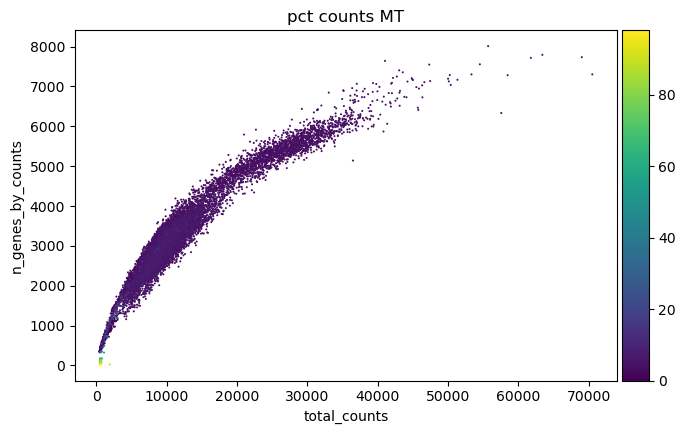

In [20]:
sc.pl.scatter(fresh_blood_adata, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

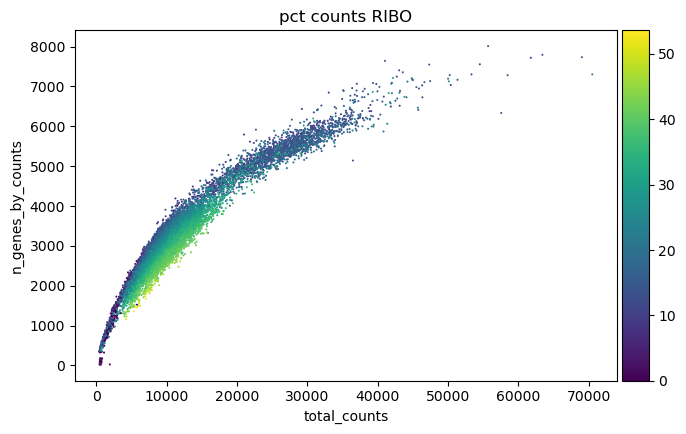

In [48]:
sc.pl.scatter(fresh_blood_adata, "total_counts", "n_genes_by_counts", color="pct_counts_RIBO")

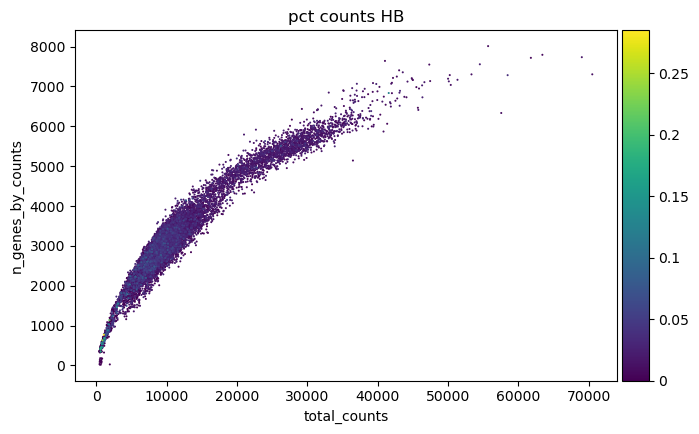

In [15]:
sc.pl.scatter(fresh_blood_adata, "total_counts", "n_genes_by_counts", color="pct_counts_HB")


# doublet detection
## Identifying doublets is crucial as they can lead to misclassifications or
## distortions in downstream analysis steps

In droplet-based technologies (like 10x Genomics), each droplet is supposed to capture one cell.
But sometimes:

*Two cells enter the same droplet.* Their RNA gets captured together and he sequencer thinks it is one cell. This creates a doublet, which has:

- abnormally high total counts,

- abnormally high number of detected genes,

- mixed expression signatures from two cell types.

Doublets mess up clustering and can create fake new clusters. 

`sc.pp.scrublet(fresh_blood_adata)` runs the Scrublet algorithm on your data.

Scrublet:

-Simulates fake doublets by computationally merging pairs of cells in your dataset

-Learns what a doublet “looks like”

-Uses a nearest-neighbors model to assign each cell a doublet score

-Predicts whether each cell is a singlet or doublet

In [10]:
sc.pp.scrublet(fresh_blood_adata) #use batch key if there are mutiple samples

In [11]:
#inspect 

fresh_blood_adata.obs['predicted_doublet'].value_counts()
fresh_blood_adata.obs[['doublet_score', 'predicted_doublet']].head()


,doublet_score,predicted_doublet
AAACCAAAGAACAGAC-1,0.015498,False
AAACCAAAGCAAGATA-1,0.022246,False
AAACCAAAGCTGGTTA-1,0.020822,False
AAACCAGCACCTAACG-1,0.011241,False
AAACCAGCACGCGTTA-1,0.060390,False


In [12]:
#filter the cells which are not doublet

fresh_blood_adata = fresh_blood_adata[
    ~fresh_blood_adata.obs['predicted_doublet'],
    :
]

#check how cells where droped checking the nubler of predicted roublet

fresh_blood_adata.obs['predicted_doublet'].sum()


np.int64(0)

## Normalization
Normalization adjusts for sequencing depth differences between cells. Here, we scale counts so each cell has the same total expression level.

In [13]:
fresh_blood_adata.layers["counts"] = fresh_blood_adata.X.copy()

# check the layers

fresh_blood_adata.layers.keys()

C:\Users\USER\AppData\Local\Temp\ipykernel_15140\4159360170.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  fresh_blood_adata.layers["counts"] = fresh_blood_adata.X.copy()


KeysView(Layers with keys: counts)

In [15]:
# Normalizing to median total counts
sc.pp.normalize_total(fresh_blood_adata)

# Logarithmize the data

sc.pp.log1p(fresh_blood_adata)



In [16]:

#Feature selection
#selecting the top 1000 most variable genes

sc.pp.highly_variable_genes(fresh_blood_adata, n_top_genes=1000)

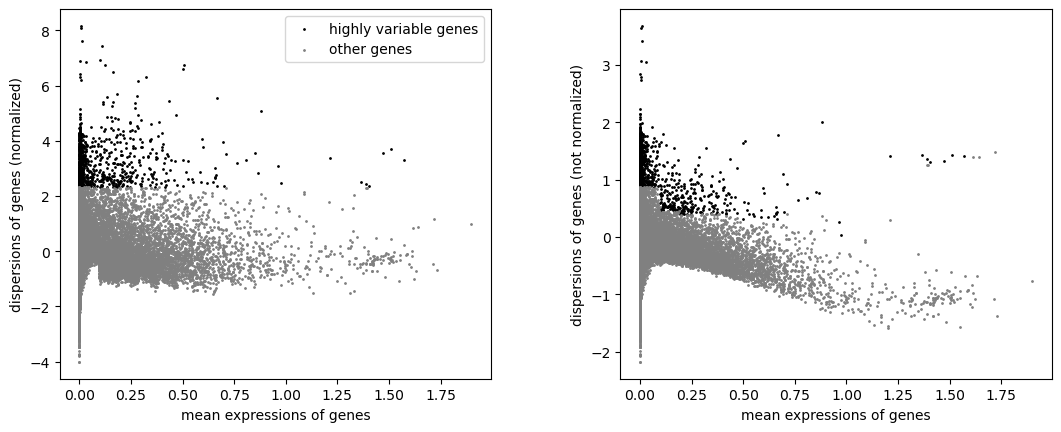

In [17]:

sc.pl.highly_variable_genes(fresh_blood_adata )
#left is normalized
#right is not

## 🔍 Dimensionality Reduction (PCA)
We use Principal Component Analysis (PCA) to reduce data complexity and highlight key variation patterns. This makes later steps like clustering and visualization faster and more robust.

In single-cell RNA-seq, each cell has expression values for thousands of genes, creating a huge, noisy matrix. PCA compresses this high-dimensional data into a smaller set of features (typically 30–50 components) that summarize the key biological and technical variation across cells.

- Noise reduction: scRNA-seq data are sparse and noisy. PCA focuses on the strongest correlated gene expression patterns, discarding random noise.

- Computational efficiency: Downstream analyses like clustering, UMAP, or t-SNE run much faster and more robustly on 30 PCs than on 20,000 genes.

- Signal extraction: The top PCs often correspond to meaningful biological structure—cell type, cell cycle state, or activation level—while later PCs capture less relevant variation.

In [21]:
sc.tl.pca(fresh_blood_adata)

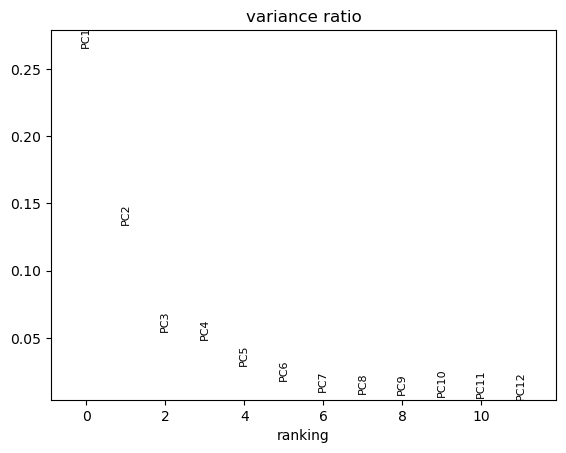

In [22]:

sc.pl.pca_variance_ratio(fresh_blood_adata, n_pcs=11, log=False)

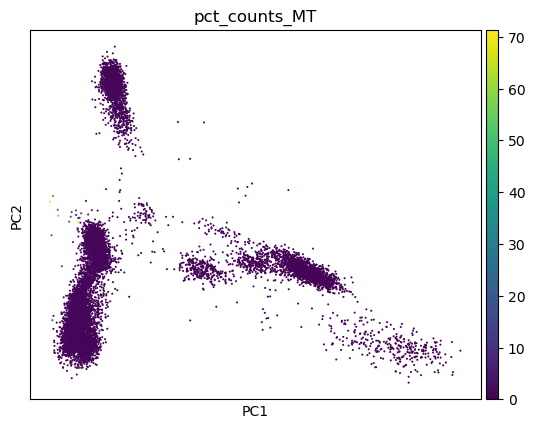

In [28]:
sc.pl.pca(fresh_blood_adata, color=["pct_counts_MT"])

#### Nearest Neighbour
Let us compute the neighborhood graph of cells using the PCA representation of the data matrix.
Basically we want to cluster the PCA components

In [29]:
sc.pp.neighbors(fresh_blood_adata)

In [30]:
sc.tl.umap(fresh_blood_adata)

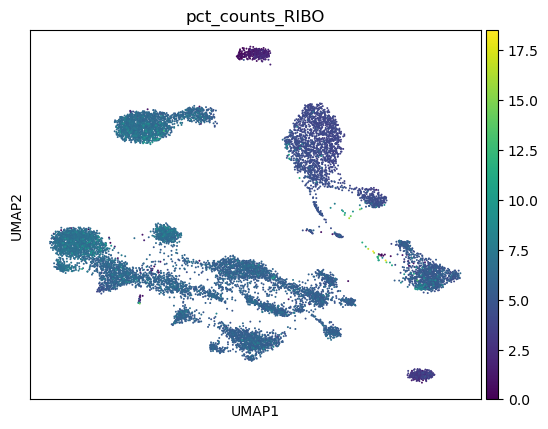

In [31]:
sc.pl.umap(fresh_blood_adata, size=8, color=["pct_counts_RIBO"])

### Clustering by communities.

Clustering by communities in single-cell RNA-seq is the process of grouping cells that show similar expression profiles — essentially, discovering putative cell types or states.

Once PCA compresses your data into a manageable set of dimensions, clustering algorithms like Leiden operate on a graph-based representation of cell–cell relationships.

Usually used for cell type detection

In [32]:
sc.tl.leiden(fresh_blood_adata, flavor="igraph", n_iterations=2)

             # Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets


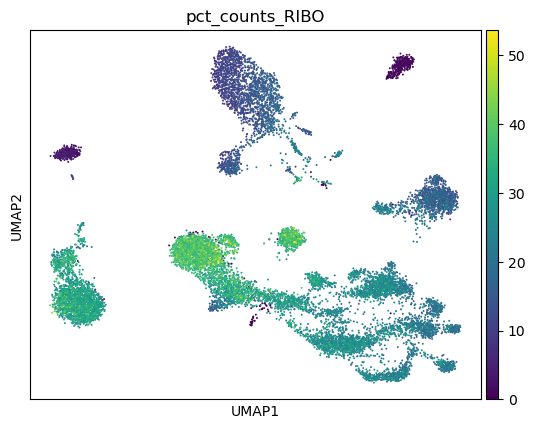

In [43]:

sc.pl.umap(
    fresh_blood_adata,
    color=["pct_counts_RIBO"],
    size=8,
)

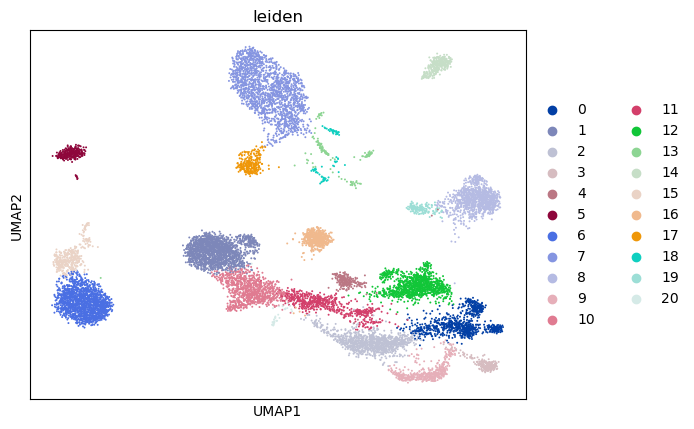

In [44]:
sc.pl.umap(
    fresh_blood_adata,
    color=["leiden"],
    size=8,
)

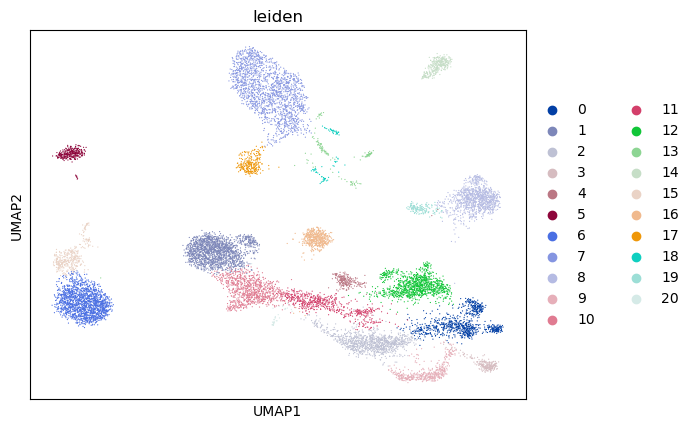

In [45]:
sc.pl.umap(
    fresh_blood_adata,
    color=["leiden"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

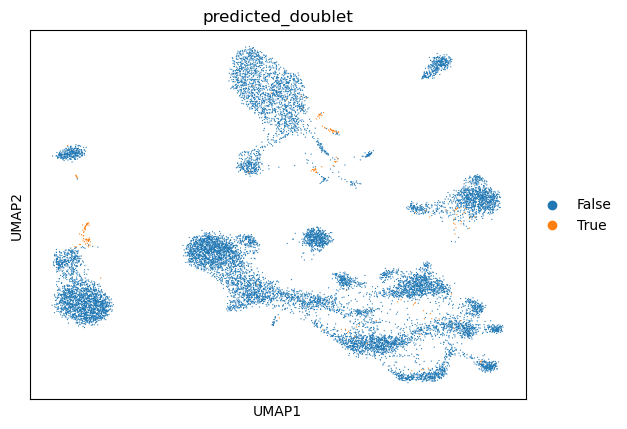

In [47]:
sc.pl.umap(
    fresh_blood_adata,
    color=[ "predicted_doublet"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

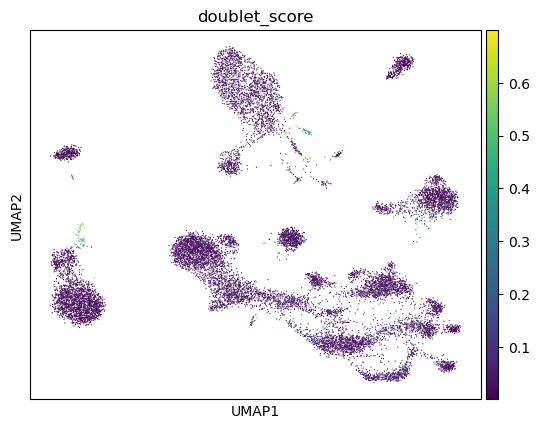

In [48]:
sc.pl.umap(
    fresh_blood_adata,
    color=[ "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

Re-run Leiden clustering at multiple resolutions to capture cell populations at different granularity.  
Low resolution groups broad cell types, while high resolution can reveal finer subtypes or rare cells.  
Storing each result separately allows comparison without overwriting previous clusters.

In [33]:
#further reclustering

sc.tl.leiden(fresh_blood_adata, flavor="igraph", n_iterations=2, key_added="leiden_res0_02", resolution=0.02)
sc.tl.leiden(fresh_blood_adata, flavor="igraph", n_iterations=2, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(fresh_blood_adata, flavor="igraph", n_iterations=2, key_added="leiden_res2", resolution=2)


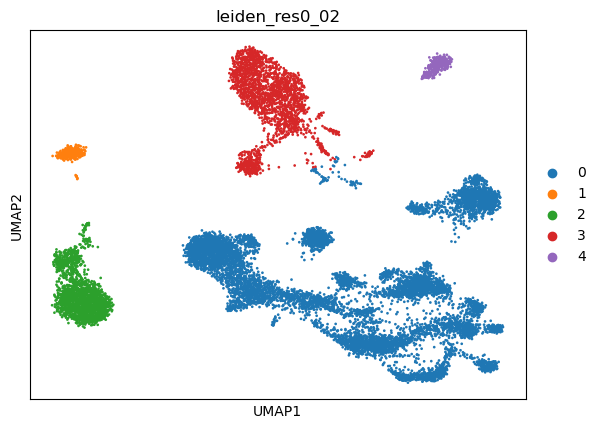

In [50]:

sc.pl.umap(
    fresh_blood_adata,
    color=["leiden_res0_02"],
    # increase horizontal space between panels
    wspace=0.5,
    size=15,
    ncols = 1
)

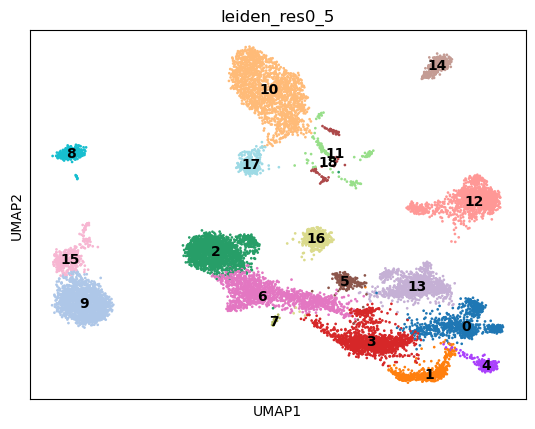

In [51]:

sc.pl.umap(
    fresh_blood_adata,
    color=["leiden_res0_5"],
    # increase horizontal space between panels
    wspace=0.5,
    size=15,
    ncols = 1,
    legend_loc="on data"
)

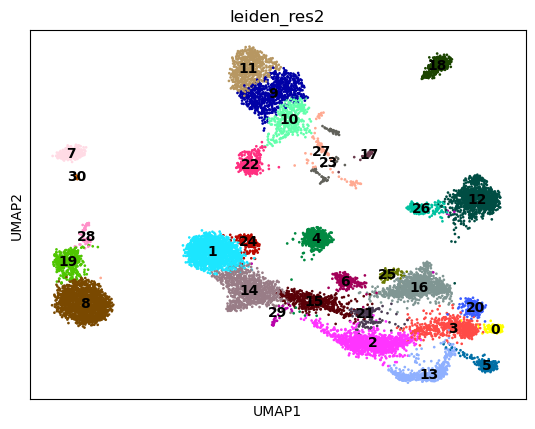

In [52]:
sc.pl.umap(
    fresh_blood_adata,
    color=["leiden_res2"],
    # increase horizontal space between panels
    wspace=0.5,
    size=15,
    ncols = 1,
    legend_loc="on data"
)

### Cell Annotation
Cell annotation is the process of assigning biological meaning—like cell type or functional state—to each cluster found after Leiden clustering.

Traditionally, this relies on manual marker gene inspection: you identify top genes per cluster and match them to known markers. But tools like Decoupler enable a more systematic and data-driven approach.

Decoupler is a framework for gene set activity inference. Instead of labeling clusters by single markers, it estimates the activity of predefined pathways, transcription factors, or cell-type signatures from known databases (e.g., MSigDB, PROGENy, DoRothEA).

In practice:

- You provide your normalized expression matrix (adata).

- You load gene sets representing known biological programs or cell-type signatures.

- Decoupler calculates an activity score per cell or cluster using methods like weighted mean, ULM, or AUCell.

- You interpret those activities to annotate clusters automatically or semi-automatically.

In [34]:

import decoupler as dc

In [35]:
# Query OmniPath to download the PanglaoDB cell type marker database (for human)
markers = dc.op.resource(name="PanglaoDB", organism="human")

# Keep only markers flagged as canonical (most reliable markers per cell type)
markers = markers[markers["canonical_marker"]]

# Remove duplicate cell_type–gene combinations
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Rename columns because decoupler expects 'source' (cell type) and 'target' (marker gene)
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})

# Keep only the required columns
markers = markers[["source", "target"]]

# Preview output
markers.head()


,source,target
,,
2,Bergmann glia,A2M
4,Mast cells,A4GALT
5,Embryonic stem cells,A7KBS4
8,Pinealocytes,AANAT
9,Astrocytes,AANAT


In [36]:
#load the gene expression matrix into dc

dc.mt.ulm(data=fresh_blood_adata,
          net=markers,
          tmin = 3)

In [37]:
#retrieve the score for each cell type

score = dc.pp.get_obsm(fresh_blood_adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 13663 × 142
    obs: 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO', 'log1p_total_counts_RIBO', 'pct_counts_RIBO', 'total_counts_HB', 'log1p_total_counts_HB', 'pct_counts_HB', 'leiden', 'leiden_res0_02', 'leiden_res0_5', 'leiden_res2'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_res0_02', 'leiden_res0_5', 'leiden_res2'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'

In [38]:

#preview the data
fresh_blood_adata.obsm["score_ulm"].head()

,Acinar cells,Adipocyte progenitor cells,Adipocytes,Adrenergic neurons,Airway goblet cells,Alpha cells,Alveolar macrophages,Anterior pituitary gland cells,Astrocytes,B cells,...,T helper cells,T memory cells,T regulatory cells,Tanycytes,Taste receptor cells,Thymocytes,Trichocytes,Trophoblast cells,Tuft cells,Urothelial cells
AAACCAAAGAACAGAC-1,-1.836148,-0.762066,-0.963597,-0.901724,-0.077158,-1.255648,2.662449,-1.022498,1.070223,2.385575,...,3.837206,3.158957,0.867254,-0.816834,-0.637907,6.566242,-0.590271,-0.762066,2.119276,-0.453720
AAACCAAAGCAAGATA-1,-1.631774,-0.677251,-1.343312,-0.801364,-0.957868,0.849827,0.149099,-0.908696,0.832952,4.557466,...,1.679269,6.274232,-0.394662,-0.792428,0.209863,4.245814,-0.524576,0.447310,1.169440,-1.004639
AAACCAAAGCTGGTTA-1,-1.378350,-0.746277,-0.591741,-0.883040,-1.055496,1.083933,1.253895,-1.001312,0.199635,4.347363,...,2.175605,5.336893,-1.203519,-0.776635,0.086560,5.009434,-0.578041,0.685961,2.135823,-1.107034
AAACCAGCACCTAACG-1,-1.780746,-0.739075,-1.908035,-0.874518,-1.045309,0.311035,2.277548,-0.991649,1.745991,1.886741,...,3.533440,3.126522,-1.191905,-1.478574,-0.580537,5.174908,-0.572463,2.397619,2.808434,-1.096351
AAACCAGCACGCGTTA-1,-1.405662,-0.748522,-1.438591,-0.885697,-1.058671,0.715510,1.998421,-1.004325,1.408768,4.125069,...,3.072874,2.644065,-1.207141,-1.018501,-0.633144,7.639385,-0.579780,2.007104,2.010185,-0.464649


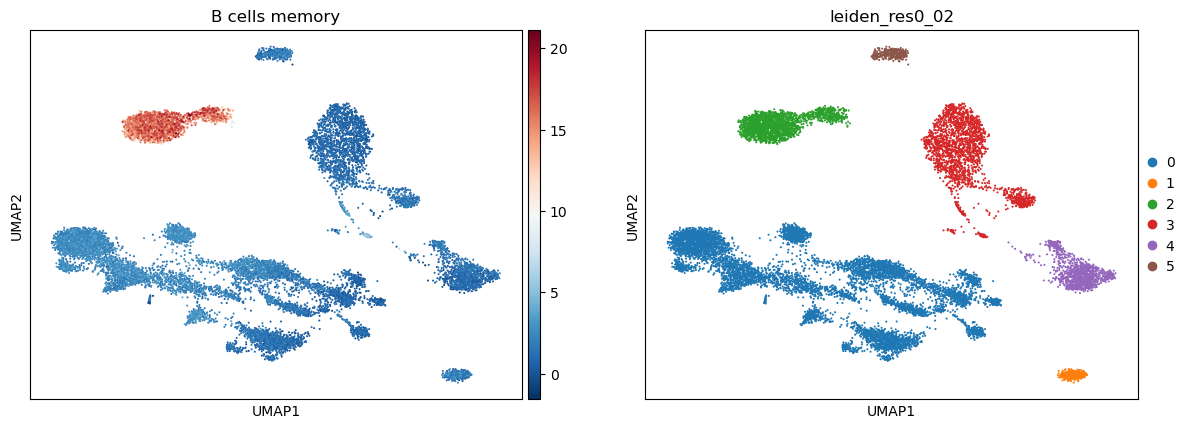

In [39]:
sc.pl.umap(score, color=["B cells memory", "leiden_res0_02"], cmap="RdBu_r")

In [40]:

import seaborn as sns

2025-11-25 15:04:40 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-25 15:04:40 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-25 15:04:40 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-25 15:04:40 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-25 15:04:40 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

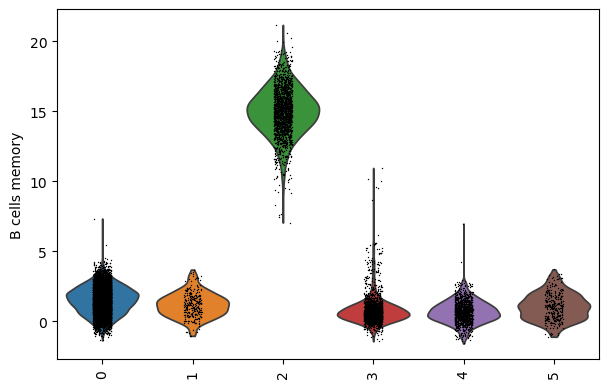

In [41]:
sc.pl.violin(score, keys=["B cells memory"], groupby="leiden_res0_02", rotation=90)

In [42]:
#rank genes
fresh_blood_adata_rank = dc.tl.rankby_group(score, groupby="leiden_res0_02", reference="rest", method="t-test_overestim_var")
fresh_blood_adata_rank = fresh_blood_adata_rank[fresh_blood_adata_rank["stat"] > 0]
fresh_blood_adata_rank.head()

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,T cells,211.428799,11.052616,0.0,0.0
1,0,rest,Nuocytes,178.866967,2.387737,0.0,0.0
2,0,rest,Thymocytes,125.505346,2.790009,0.0,0.0
3,0,rest,T helper cells,89.027498,1.367606,0.0,0.0
4,0,rest,Germ cells,64.714445,0.761487,0.0,0.0


In [43]:
cluster_annotations = fresh_blood_adata_rank[fresh_blood_adata_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
     

C:\Users\USER\AppData\Local\Temp\ipykernel_15140\3279758270.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_annotations = fresh_blood_adata_rank[fresh_blood_adata_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


In [44]:
cluster_annotations

{'0': 'T cells',
 '1': 'Basophils',
 '2': 'B cells memory',
 '3': 'Macrophages',
 '4': 'Gamma delta T cells',
 '5': 'Purkinje neurons'}

In [45]:
fresh_blood_adata.obs['cell_type'] = fresh_blood_adata.obs['leiden_res0_02'].map(cluster_annotations)

In [46]:
# Example of how to subset for multiple genes in the 'source' column
available_genes = set(fresh_blood_adata.var_names)

b_cell_markers = markers[markers['source'].isin(['B cells memory'])]['target']
b_cell_markers = b_cell_markers[b_cell_markers.isin(available_genes)]

nk_cell_markers = markers[markers['source'].isin(['Natural killer T cells'])]['target']
nk_cell_markers = nk_cell_markers[nk_cell_markers.isin(available_genes)]

t_cells_markers = markers[markers['source'].isin(['T cells'])]['target']
t_cells_markers = t_cells_markers[t_cells_markers.isin(available_genes)]


#display(b_cell_markers)

### Other ways to visualize the cell types

In [47]:
marker_genes_dict = {
    "B cells": b_cell_markers.head().tolist(),
    "NK cells": nk_cell_markers.head().tolist(),
    "T cells": t_cells_markers.head().tolist()
}

categories: T cells, Basophils, B cells memory, etc.
var_group_labels: B cells, NK cells, T cells


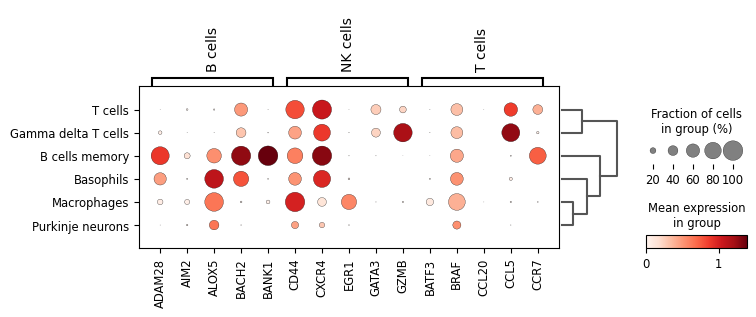

In [48]:

sc.pl.dotplot(fresh_blood_adata, marker_genes_dict, "cell_type", dendrogram=True)

categories: 0, 1, 2, etc.
var_group_labels: B cells, NK cells, T cells


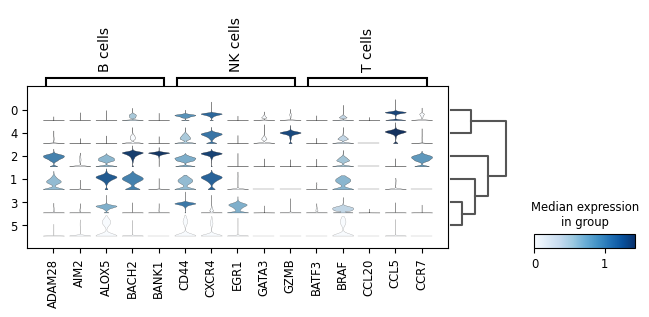

In [49]:

sc.pl.stacked_violin(
    fresh_blood_adata, marker_genes_dict, groupby="leiden_res0_02",  dendrogram=True
)



categories: 0, 1, 2, etc.
var_group_labels: B cells, NK cells, T cells


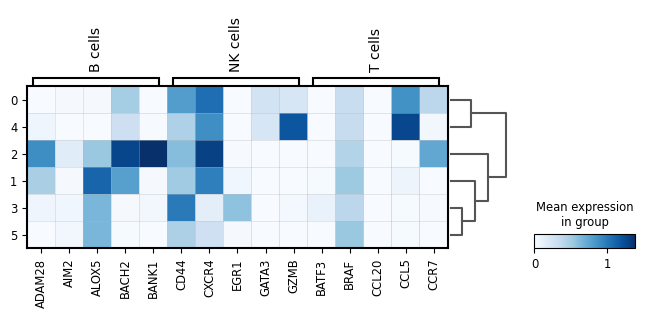

In [50]:
sc.pl.matrixplot(
    fresh_blood_adata,
    marker_genes_dict,
    "leiden_res0_02",
    dendrogram=True,
    cmap="Blues",
)

categories: 0, 1, 2, etc.
var_group_labels: B cells, NK cells, T cells


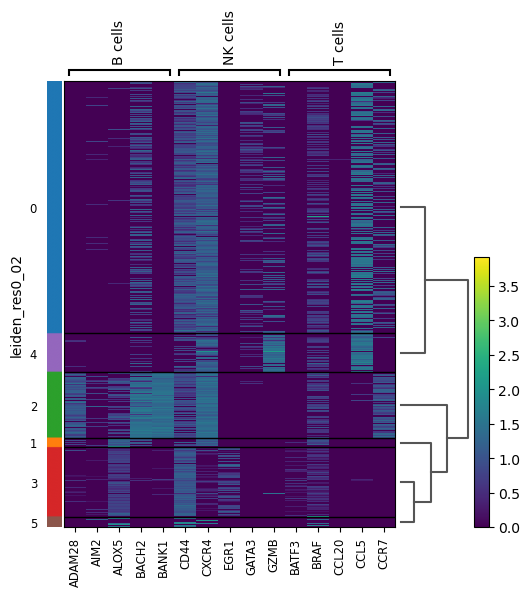

In [51]:
sc.pl.heatmap(
    fresh_blood_adata, marker_genes_dict, groupby="leiden_res0_02", cmap="viridis", dendrogram=True
)

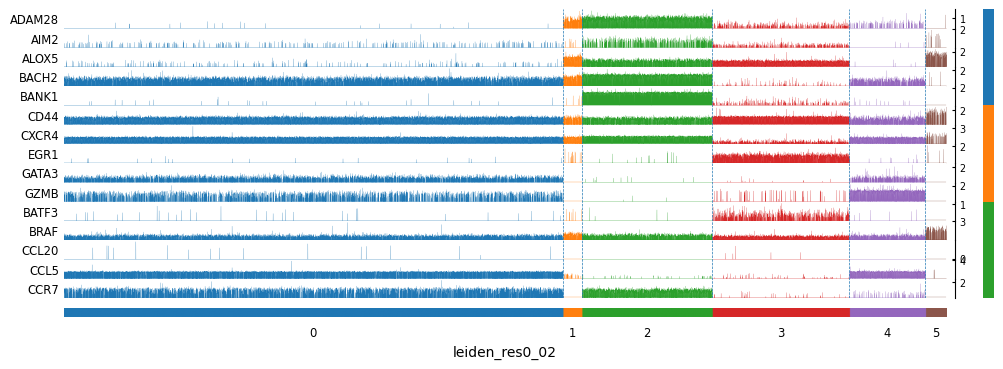

In [52]:
# @title Using genome tracks
sc.pl.tracksplot(fresh_blood_adata, marker_genes_dict, groupby="leiden_res0_02", dendrogram=False)